In [1]:
%matplotlib widget

#### Plot scores across one prompt type

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

def load_data(file_path):
    """
    Reads the CSV file and returns a pandas DataFrame.
    """
    try:
        df = pd.read_csv(file_path)
        print(f"Successfully loaded data from {file_path}")
        return df
    except FileNotFoundError:
        print(f"Error: The file {file_path} was not found.")
        return None


def plot_scores(df, prompt_type):
    """
    Filters data by prompt_type, sorts by Final Score, and generates a bar chart.
    Dynamically adjusts the figure width to ensure bars and labels are spaced out.
    Includes both the Optimal Layer on top and the Final Score at the bottom.
    """
    # Filter the data based on the prompt type
    filtered_df = df[df['Prompt Type'] == prompt_type].copy()
    
    if filtered_df.empty:
        print(f"No data found for Prompt Type: {prompt_type}")
        return

    # Sort the data by 'Final Score' (descending order)
    sorted_df = filtered_df.sort_values(by='Final Score', ascending=False)

    # Calculate width: give each bar roughly 0.35 inches of space
    # Ensure a minimum width of 12 inches just in case the dataset is small
    num_bars = len(sorted_df)
    dynamic_width = max(12, num_bars * 0.35) 
    
    # Set up the plot with the dynamic width
    fig, ax = plt.subplots(figsize=(dynamic_width, 8)) 
    
    # Create the bars
    bars = ax.bar(sorted_df['Concept'], sorted_df['Final Score'], color='steelblue', edgecolor='black')

    # Format the X-axis to have vertical labels
    plt.xticks(rotation=90, fontsize=10)
    
    # Set labels and title
    ax.set_xlabel('Concept', fontsize=12, fontweight='bold')
    ax.set_ylabel('Final Score', fontsize=12, fontweight='bold')
    ax.set_title(f'Final Scores by Concept (Prompt Type {prompt_type})', fontsize=14, fontweight='bold')

    # Display the labels on the bars
    for bar, layer in zip(bars, sorted_df['Optimal Layer']):
        height = bar.get_height()
        
        # 1. Optimal Layer at the top
        layer_text = str(int(layer)) if pd.notna(layer) else "N/A" 
        ax.text(
            bar.get_x() + bar.get_width() / 2, 
            max(height, 0.075),                            
            layer_text,                        
            ha='center',                       
            va='bottom',                       
            fontsize=9,
            color='black'
        )



        smart_color = 'white' if height > 0.065 else 'black'

        # 2. Final Score at the bottom, vertically
        ax.text(
            bar.get_x() + bar.get_width() / 2, 
            0.01,                           # Positioned just slightly above the x-axis
            f"{height:.5f}",                # Formatted to 4 decimal places
            ha='center',                       
            va='bottom',                       
            rotation=90,                    # Rotated vertically
            fontsize=9,
            color= smart_color,                  # White text contrasts well against the blue bar
            # fontweight='bold'
        )

        

    # Adjust layout so the vertical labels don't get cut off
    plt.tight_layout()

    # Save and display
    plt.savefig(f"concept_scores_plot_type{prompt_type}.png", bbox_inches="tight")
    plt.show()

In [4]:
# def plot_type1_vs_type2(df):
#     """
#     Creates a proportional 1:1 scatter plot comparing Final Scores.
#     """
#     # 1. Separate and merge the data
#     df_type1 = df[df['Prompt Type'] == 1][['Concept', 'Final Score']]
#     df_type2 = df[df['Prompt Type'] == 2][['Concept', 'Final Score']]
#     merged_df = pd.merge(df_type1, df_type2, on='Concept', suffixes=('_type1', '_type2'))
    
#     # 2. Set up the plot (using a square figure size helps)
#     fig, ax = plt.subplots(figsize=(8, 8)) 
    
#     # 3. Create the scatter plot
#     ax.scatter(
#         merged_df['Final Score_type1'], 
#         merged_df['Final Score_type2'], 
#         color='steelblue',      
#         edgecolor='black',      
#         alpha=0.8,              
#         s=60                    
#     )
    
#     # --- THE FIX: PROPORTIONAL SCALING ---
#     # Find the absolute min and max across BOTH axes to lock them into the exact same scale
#     min_val = min(merged_df['Final Score_type1'].min(), merged_df['Final Score_type2'].min())
#     max_val = max(merged_df['Final Score_type1'].max(), merged_df['Final Score_type2'].max())
    
#     # Add a little padding so dots don't ride the exact edges of the graph
#     padding = (max_val - min_val) * 0.05
#     min_val -= padding
#     max_val += padding

#     # Force both axes to have the exact same limits
#     ax.set_xlim(min_val, max_val)
#     ax.set_ylim(min_val, max_val)
    
#     # Force the physical aspect ratio of the plot to be exactly 1:1
#     ax.set_aspect('equal', adjustable='box')
    
#     # Add a y=x diagonal line for perfect visual comparison
#     ax.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', alpha=0.5, label='Equal Score (y=x)')

#     # 4. Add titles and labels
#     ax.set_title('Concept Scores: Prompt Type 1 vs. Prompt Type 2', fontsize=14, fontweight='bold')
#     ax.set_xlabel('Score on Prompt Type 1', fontsize=12, fontweight='bold')
#     ax.set_ylabel('Score on Prompt Type 2', fontsize=12, fontweight='bold')
    
#     # 5. Add the proportional grid and legend
#     ax.grid(True, linestyle='--', alpha=0.7)
#     ax.legend(loc='upper left')
    
#     # Save and display
#     plt.tight_layout()
#     plt.savefig("type1_vs_type2_proportional.png", bbox_inches="tight")
#     plt.show()

### Plot type 1 vs type 2

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

def plot_type2_vs_type1(df):
    """
    Creates a proportional 1:1 scatter plot comparing Final Scores.
    X-axis: Prompt Type 2
    Y-axis: Prompt Type 1
    Features a denser grid with more tick values.
    """
    # 1. Separate and merge the data
    df_type1 = df[df['Prompt Type'] == 1][['Concept', 'Final Score']]
    df_type2 = df[df['Prompt Type'] == 2][['Concept', 'Final Score']]
    merged_df = pd.merge(df_type1, df_type2, on='Concept', suffixes=('_type1', '_type2'))
    
    # 2. Set up the plot
    fig, ax = plt.subplots(figsize=(9, 9)) 
    
    # 3. Find the absolute min and max across BOTH axes to lock them into the exact same scale
    min_val = min(merged_df['Final Score_type1'].min(), merged_df['Final Score_type2'].min())
    max_val = max(merged_df['Final Score_type1'].max(), merged_df['Final Score_type2'].max())
    
    # Add a little padding so dots don't ride the exact edges
    padding = (max_val - min_val) * 0.05
    min_val -= padding
    max_val += padding

    # 4. Create the scatter plot (Type 2 on X, Type 1 on Y)
    ax.scatter(
        merged_df['Final Score_type2'], # Now X-axis
        merged_df['Final Score_type1'], # Now Y-axis
        color='steelblue',      
        edgecolor='black',      
        alpha=0.8,              
        s=60                    
    )

    # Force both axes to have the exact same limits
    ax.set_xlim(min_val, max_val)
    ax.set_ylim(min_val, max_val)
    
    # Force the physical aspect ratio of the plot to be exactly 1:1
    ax.set_aspect('equal', adjustable='box')
    
    # --- NEW: MORE VALUES ON X AND Y AXES ---
    # Generate 15 evenly spaced ticks between min_val and max_val
    tick_marks = np.linspace(min_val, max_val, 15)
    ax.set_xticks(tick_marks)
    ax.set_yticks(tick_marks)
    
    # Format ticks to 2 decimal places to keep the dense grid readable
    ax.xaxis.set_major_formatter(plt.FormatStrFormatter('%.2f'))
    ax.yaxis.set_major_formatter(plt.FormatStrFormatter('%.2f'))
    
    # Rotate x-axis labels so the extra numbers don't crash into each other
    plt.xticks(rotation=45)

    # Add a y=x diagonal line for perfect visual comparison
    ax.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', alpha=0.5, label='Equal Score (y=x)')

    # 5. Add titles and labels (Swapped)
    ax.set_title('Concept Scores: Prompt Type 2 vs. Prompt Type 1', fontsize=14, fontweight='bold')
    ax.set_xlabel('Score on Prompt Type 2', fontsize=12, fontweight='bold')
    ax.set_ylabel('Score on Prompt Type 1', fontsize=12, fontweight='bold')
    
    # 6. Add the proportional grid and legend
    ax.grid(True, linestyle='--', alpha=0.7)
    ax.legend(loc='upper left')
    
    # Save and display
    plt.tight_layout()
    plt.savefig("type2_vs_type1_proportional.png", bbox_inches="tight")
    plt.show()

# Example usage:
# plot_type2_vs_type1_proportional(results_df)

### Plot an interactive graph

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.widgets import Button  

def plot_interactive_scatter(df):
    """
    Creates an interactive 1:1 scatter plot with click-to-toggle labels 
    and a Reset button to clear all labels at once.
    """
    # 1. Separate and merge the data
    df_type1 = df[df['Prompt Type'] == 1][['Concept', 'Final Score']]
    df_type2 = df[df['Prompt Type'] == 2][['Concept', 'Final Score']]
    merged_df = pd.merge(df_type1, df_type2, on='Concept', suffixes=('_type1', '_type2')).reset_index(drop=True)
    
    # 2. Set up the plot
    fig, ax = plt.subplots(figsize=(9, 9)) 
    
    # Push the main graph up slightly to make room for our button at the bottom
    fig.subplots_adjust(bottom=0.15) 
    
    # 3. Find the absolute min and max
    min_val = min(merged_df['Final Score_type1'].min(), merged_df['Final Score_type2'].min())
    max_val = max(merged_df['Final Score_type1'].max(), merged_df['Final Score_type2'].max())
    
    padding = (max_val - min_val) * 0.05
    min_val -= padding
    max_val += padding

    # 4. Create the scatter plot
    scatter = ax.scatter(
        merged_df['Final Score_type1'], 
        merged_df['Final Score_type2'], 
        color='steelblue',      
        edgecolor='black',      
        alpha=0.8,              
        s=60,
        picker=5                
    )

    # Force identical limits and 1:1 physical aspect ratio
    ax.set_xlim(min_val, max_val)
    ax.set_ylim(min_val, max_val)
    ax.set_aspect('equal', adjustable='box')
    
    # Grid ticks
    tick_marks = np.linspace(min_val, max_val, 15)
    ax.set_xticks(tick_marks)
    ax.set_yticks(tick_marks)
    
    ax.xaxis.set_major_formatter(plt.FormatStrFormatter('%.2f'))
    ax.yaxis.set_major_formatter(plt.FormatStrFormatter('%.2f'))
    ax.tick_params(axis='x', rotation=45)

    # Diagonal y=x line
    ax.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', alpha=0.5, label='Equal Score (y=x)')

    # Titles and labels
    ax.set_title('Interactive Concept Scores: Prompt Type 1 vs. Prompt Type 2', fontsize=14, fontweight='bold')
    ax.set_xlabel('Score on Prompt Type 1', fontsize=12, fontweight='bold')
    ax.set_ylabel('Score on Prompt Type 2', fontsize=12, fontweight='bold')
    
    ax.grid(True, linestyle='--', alpha=0.7)
    ax.legend(loc='upper left')
    
    # ==========================================
    # --- INTERACTIVE CLICK LOGIC ---
    # ==========================================
    annotations = {}

    def on_pick(event):
        ind = event.ind[0]
        if ind in annotations:
            annotations[ind].remove()
            del annotations[ind]
        else:
            x_val = merged_df.iloc[ind]['Final Score_type1']
            y_val = merged_df.iloc[ind]['Final Score_type2']
            concept = merged_df.iloc[ind]['Concept']
            
            ann = ax.annotate(
                concept, 
                (x_val, y_val),
                xytext=(8, 8),
                textcoords='offset points',
                fontsize=10,
                bbox=dict(boxstyle="round,pad=0.3", fc="lightyellow", ec="black", alpha=0.9)
            )
            annotations[ind] = ann
        
        fig.canvas.draw_idle()

    fig.canvas.mpl_connect('pick_event', on_pick)

    # ==========================================
    # --- RESET BUTTON LOGIC ---
    # ==========================================
    # Define the coordinates for the button: [left, bottom, width, height]
    ax_reset = plt.axes([0.8, 0.025, 0.12, 0.05]) 
    
    # Create the button (let's make it a nice soft red)
    btn_reset = Button(ax_reset, 'Reset Labels', color='lightcoral', hovercolor='red')

    def reset_labels(event):
        # Loop through all visible annotations and delete them
        for ann in annotations.values():
            ann.remove()
        # Empty out the dictionary
        annotations.clear()
        # Redraw the screen so they disappear instantly
        fig.canvas.draw_idle()

    # Tell the button to run the reset_labels function when clicked
    btn_reset.on_clicked(reset_labels)

    # CRITICAL PYTHON QUIRK: We must attach the button object to the figure.
    # Otherwise, Python's garbage collector deletes the button immediately!
    fig._btn_reset = btn_reset 

    # Do not use tight_layout() here, it will mess up our custom button placement
    plt.show()

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

def plot_scatter_seamless_zoom(df):
    """
    Creates a scatter plot with smooth mouse-wheel zooming.
    Labels appear dynamically when zooming in past the threshold.
    """
    df_type1 = df[df['Prompt Type'] == 1][['Concept', 'Final Score']]
    df_type2 = df[df['Prompt Type'] == 2][['Concept', 'Final Score']]
    merged_df = pd.merge(df_type1, df_type2, on='Concept', suffixes=('_type1', '_type2'))
    
    # --- BIGGER FIGURE FOR MORE SCREEN SPACE ---
    fig, ax = plt.subplots(figsize=(12, 12)) 
    
    min_val = min(merged_df['Final Score_type1'].min(), merged_df['Final Score_type2'].min())
    max_val = max(merged_df['Final Score_type1'].max(), merged_df['Final Score_type2'].max())
    
    padding = (max_val - min_val) * 0.05
    min_val -= padding
    max_val += padding
    total_width = max_val - min_val

    ax.scatter(
        merged_df['Final Score_type1'], merged_df['Final Score_type2'], 
        color='steelblue', edgecolor='black', alpha=0.8, s=50                 
    )

    ax.set_xlim(min_val, max_val)
    ax.set_ylim(min_val, max_val)
    ax.set_aspect('equal', adjustable='box')
    
    tick_marks = np.linspace(min_val, max_val, 15)
    ax.set_xticks(tick_marks)
    ax.set_yticks(tick_marks)
    ax.xaxis.set_major_formatter(plt.FormatStrFormatter('%.2f'))
    ax.yaxis.set_major_formatter(plt.FormatStrFormatter('%.2f'))
    ax.tick_params(axis='x', rotation=45)

    ax.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', alpha=0.5, label='Equal Score (y=x)')

    ax.set_title('Seamless Zoom: Prompt Type 1 vs. Prompt Type 2', fontsize=16, fontweight='bold')
    ax.set_xlabel('Score on Prompt Type 1', fontsize=14, fontweight='bold')
    ax.set_ylabel('Score on Prompt Type 2', fontsize=14, fontweight='bold')
    ax.grid(True, linestyle='--', alpha=0.7)
    ax.legend(loc='upper left')
    
    # ==========================================
    # --- 1. ZOOM REVEAL LOGIC ---
    # ==========================================
    annotations = []
    for idx, row in merged_df.iterrows():
        ann = ax.annotate(
            row['Concept'], 
            (row['Final Score_type1'], row['Final Score_type2']),
            xytext=(6, 6), textcoords='offset points', 
            fontsize=11, # <--- LARGER FONT SIZE HERE
            alpha=0.9, visible=False,
            bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="gray", alpha=0.7) # Added a subtle background box for readability
        )
        annotations.append(ann)

    # <--- REDUCED ZOOM REQUIREMENT (Shows labels when zoomed to 40% of the graph)
    zoom_threshold = total_width * 0.40 

    def on_xlims_change(event_ax):
        x_min_current, x_max_current = event_ax.get_xlim()
        current_view_width = x_max_current - x_min_current
        should_be_visible = current_view_width < zoom_threshold
        for ann in annotations:
            ann.set_visible(should_be_visible)
            
    ax.callbacks.connect('xlim_changed', on_xlims_change)
    ax.callbacks.connect('ylim_changed', on_xlims_change)

    # ==========================================
    # --- 2. SEAMLESS SCROLL WHEEL ZOOM ---
    # ==========================================
    def zoom_factory(ax, base_scale=1.2):
        def zoom_fun(event):
            if event.xdata is None or event.ydata is None: 
                return

            cur_xlim = ax.get_xlim()
            cur_ylim = ax.get_ylim()

            if event.button == 'up':
                scale_factor = 1 / base_scale
            elif event.button == 'down':
                scale_factor = base_scale
            else:
                scale_factor = 1

            new_width = (cur_xlim[1] - cur_xlim[0]) * scale_factor
            new_height = (cur_ylim[1] - cur_ylim[0]) * scale_factor

            relx = (cur_xlim[1] - event.xdata) / (cur_xlim[1] - cur_xlim[0])
            rely = (cur_ylim[1] - event.ydata) / (cur_ylim[1] - cur_ylim[0])

            ax.set_xlim([event.xdata - new_width * (1 - relx), event.xdata + new_width * (relx)])
            ax.set_ylim([event.ydata - new_height * (1 - rely), event.ydata + new_height * (rely)])
            
            fig.canvas.draw_idle()

        fig.canvas.mpl_connect('scroll_event', zoom_fun)

    zoom_factory(ax)

    plt.tight_layout()
    plt.show()

Successfully loaded data from results/BERT_run0/BERT_scores_run0.csv


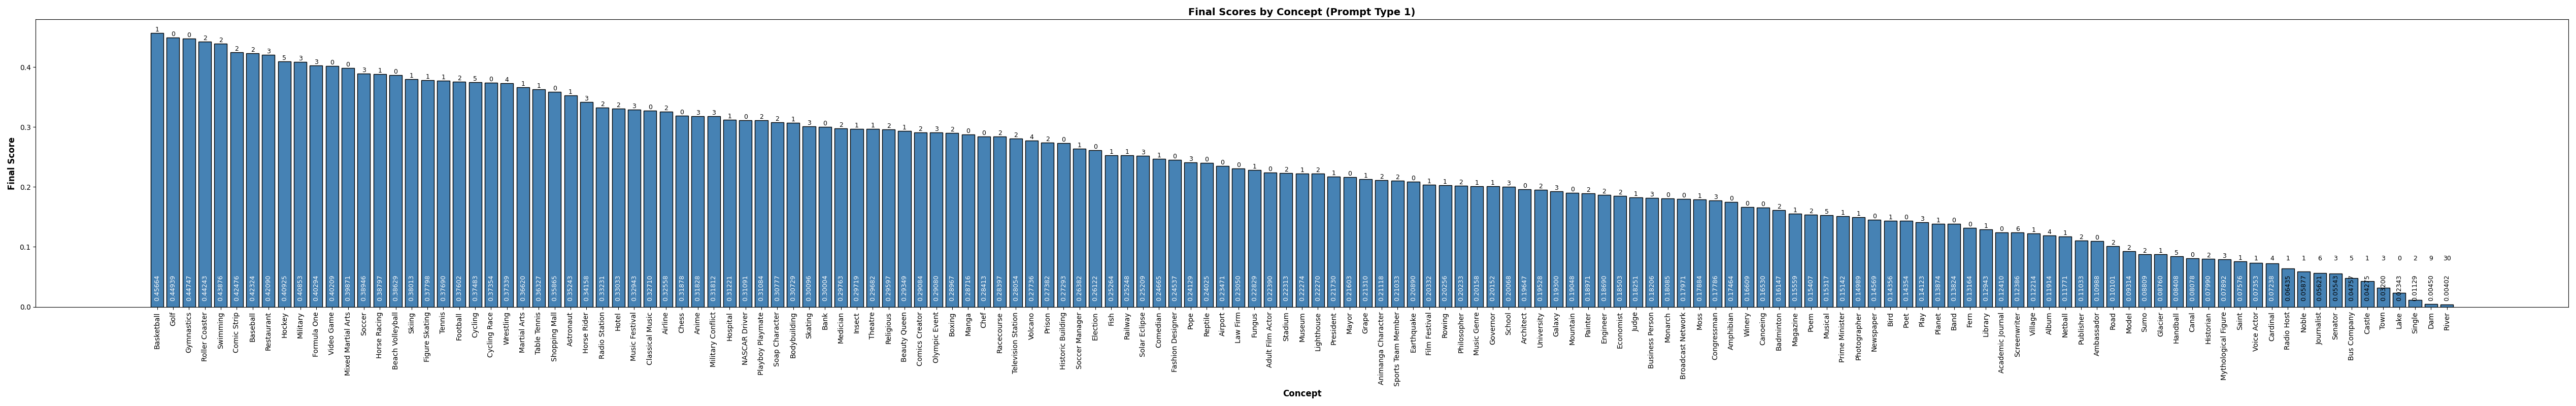

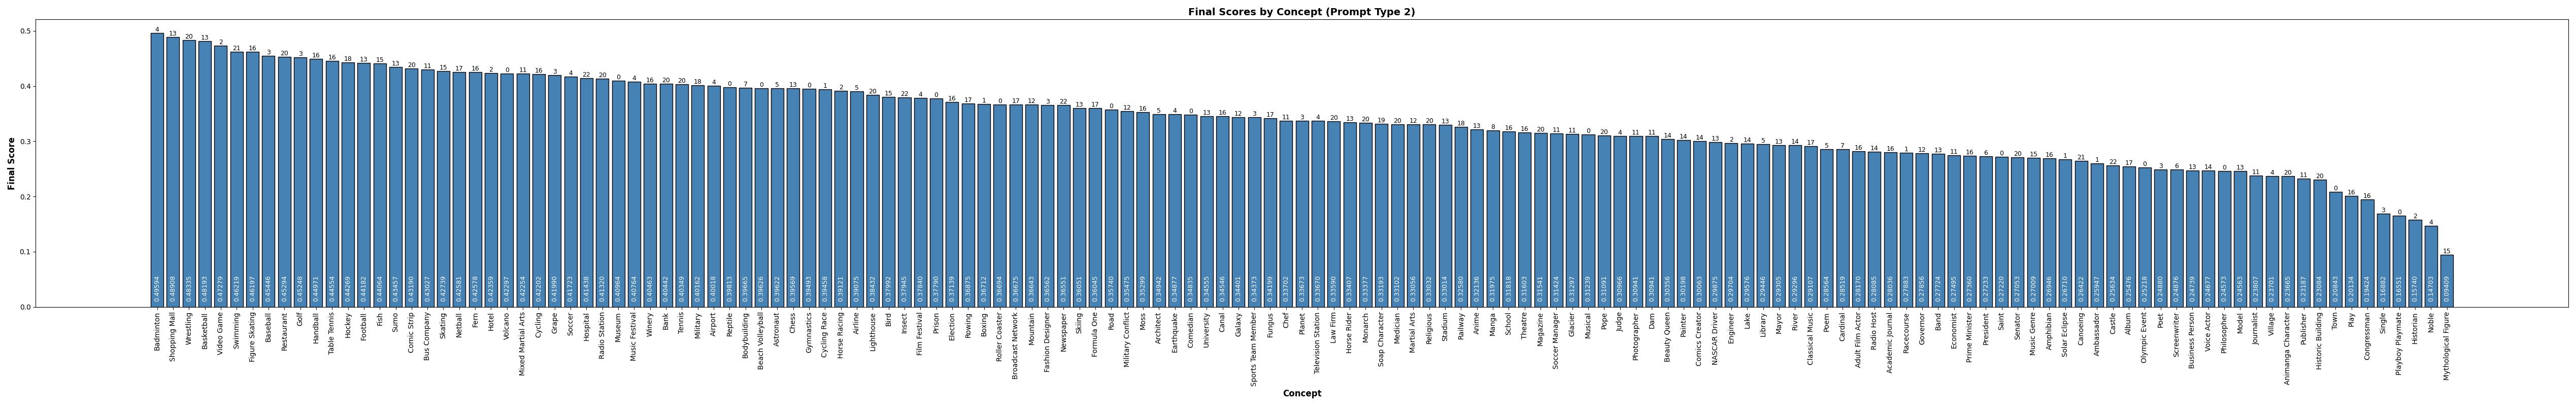

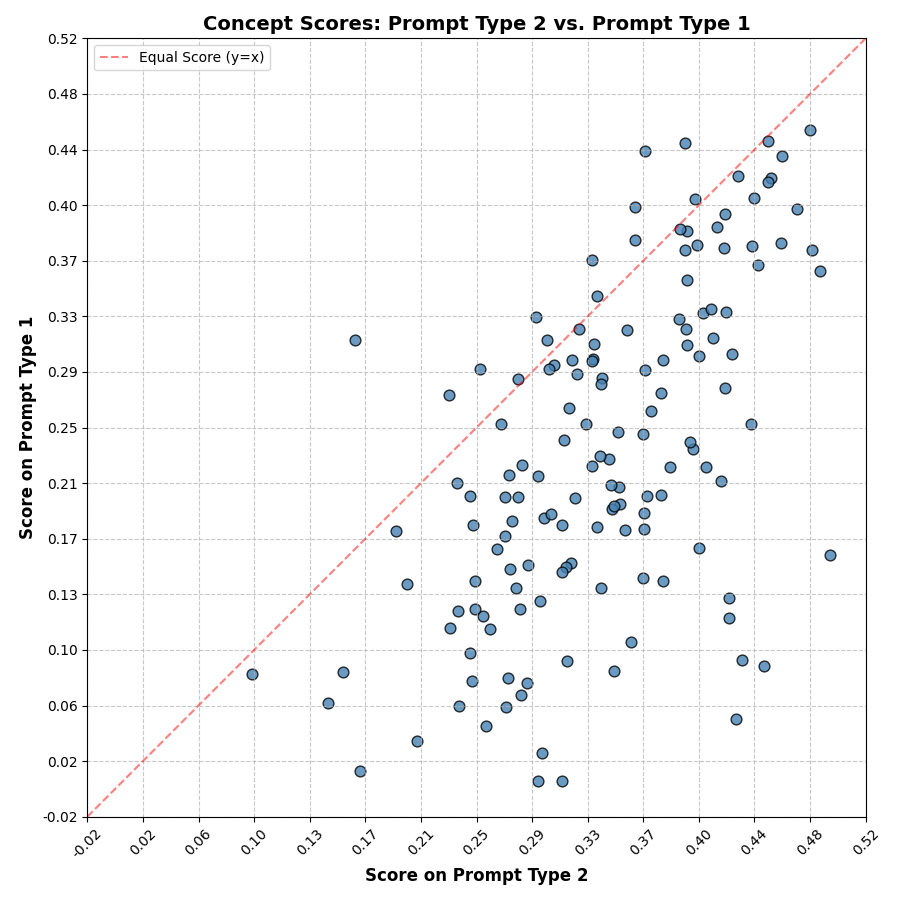

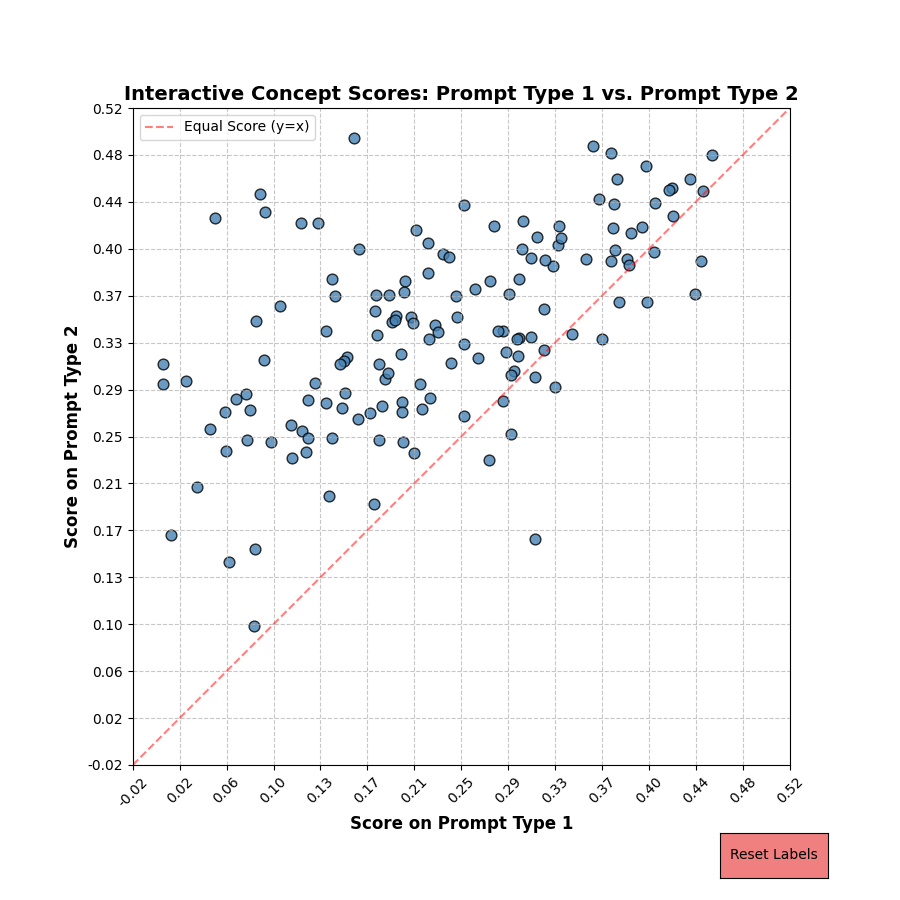

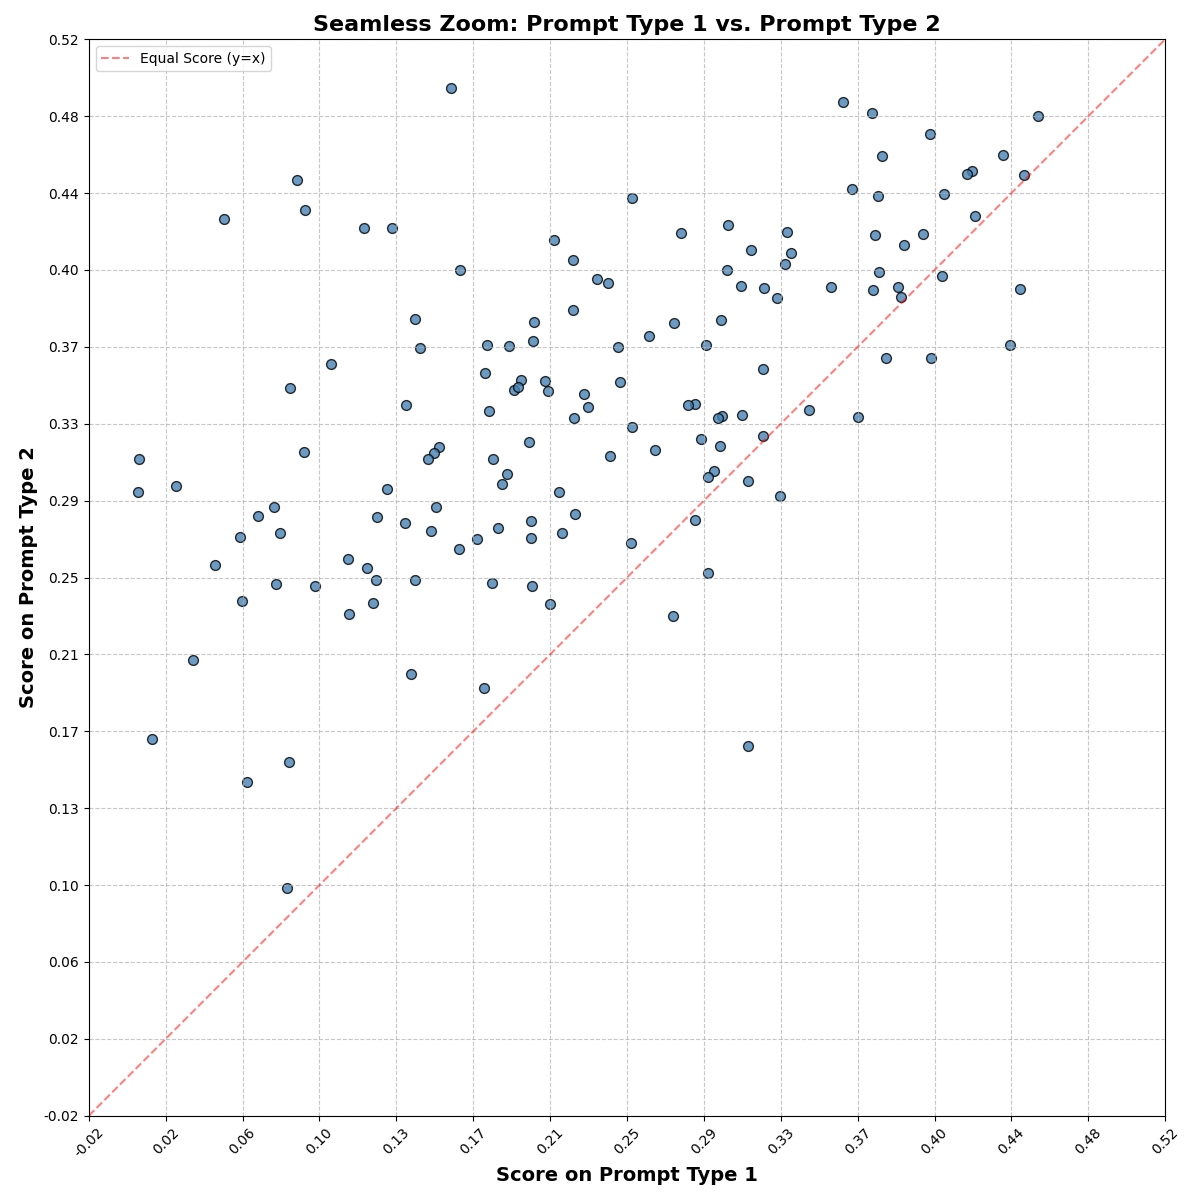

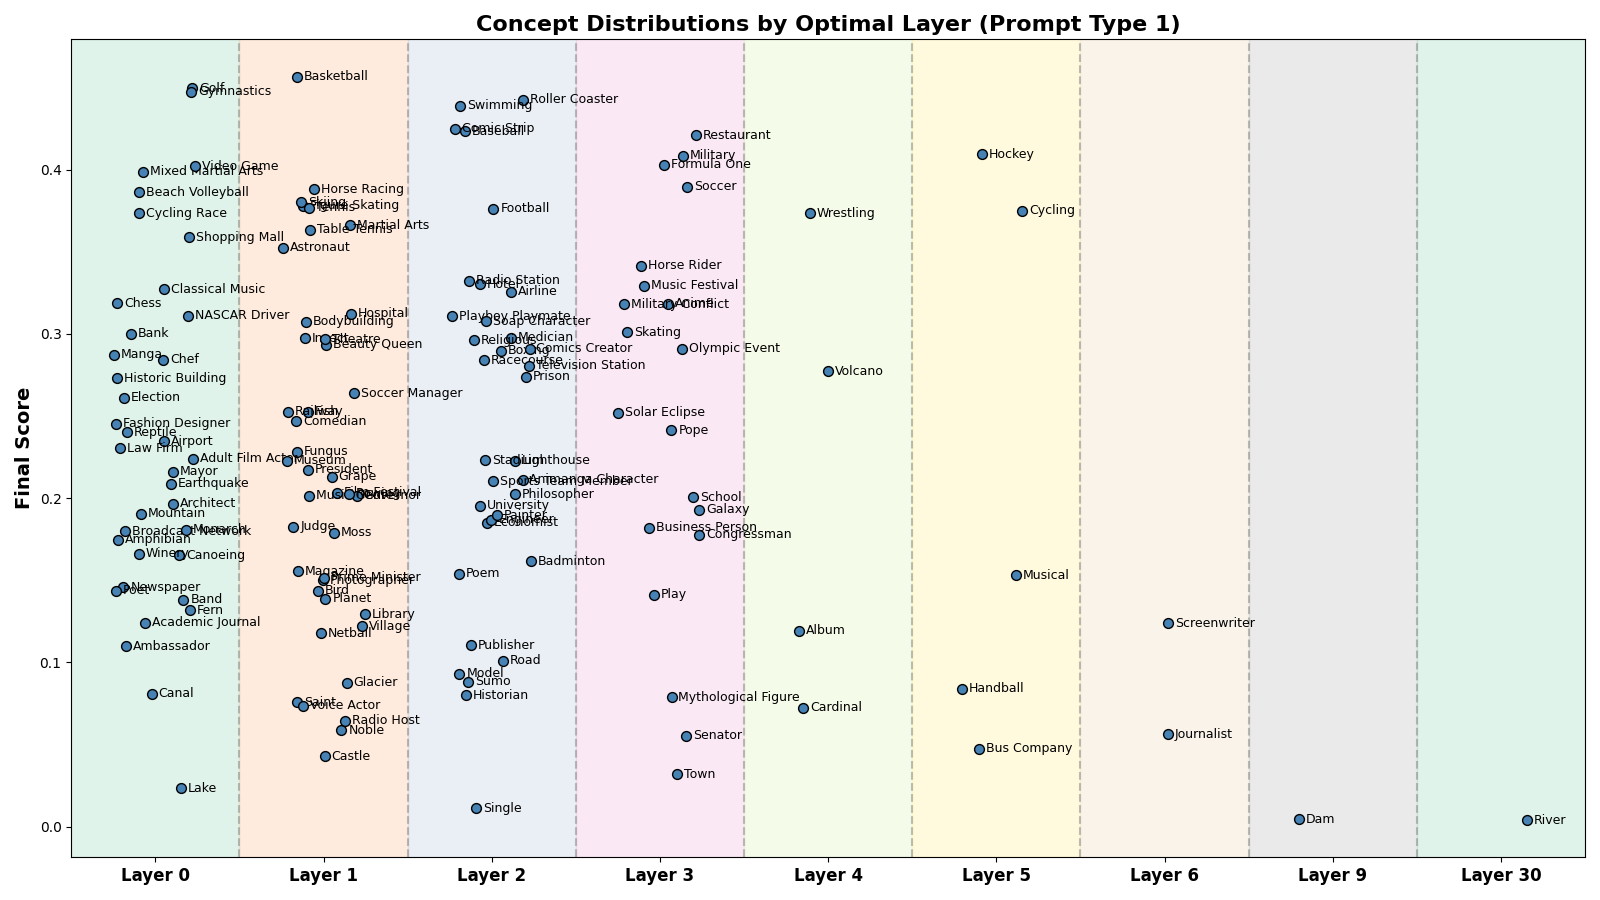

In [ ]:
# Replace 'experiment_results.csv' with your actual file name
file_name = 'results/BERT_run0/BERT_scores_run0.csv' 

# Load the data
results_df = load_data(file_name)


plot_scores(results_df, prompt_type=1)
plot_scores(results_df, prompt_type=2)



plot_type2_vs_type1(results_df)



plot_interactive_scatter(results_df)

plot_scatter_seamless_zoom(results_df)


